In [ ]:
# !pip install opencv-python

**Haar cascade**

It is an object detection method

In [3]:
import cv2

https://github.com/opencv/opencv/tree/master/data/haarcascades

**load the Frontal face filter**

In [5]:
face_cascade=cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
dir(face_cascade)

['__class__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 'convert',
 'detectMultiScale',
 'detectMultiScale2',
 'detectMultiScale3',
 'empty',
 'getFeatureType',
 'getOriginalWindowSize',
 'isOldFormatCascade',
 'load',
 'read']

#### Image:

In [7]:
# Read the image
img=cv2.imread('Benjamin-Franklin.jpg') # array wil come
cv2.imshow('image',img)  # we are showing on a window
cv2.waitKey(0)           # window will open till enter any key
cv2.destroyAllWindows()  # destroy that window

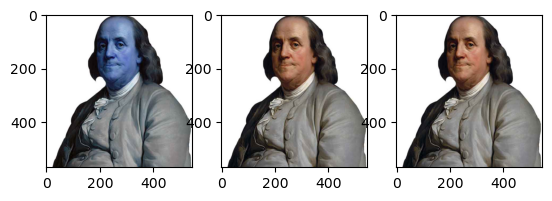

In [11]:
import matplotlib.pyplot as plt
# we read image using opencv === BGR
# we are showing with maptplotlib
img=cv2.imread('Benjamin-Franklin.jpg')
img1=plt.imread('Benjamin-Franklin.jpg')
cvt_image=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

plt.subplot(1,3,1).imshow(img)
plt.subplot(1,3,2).imshow(img1)
plt.subplot(1,3,3).imshow(cvt_image)

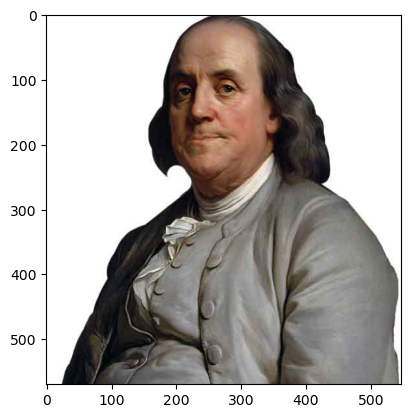

In [13]:
import matplotlib.pyplot as plt
frame=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(frame)

**cv2.rectangle**:
    
- Image paths

- start_window= (0,120)

- end_window= (250,300)

- BGR : (255,0,0)
    
- thikness= 3

**Draw a Rectangualr box manually**

- Generally every bounding box will draw like below

- It will give 4 values:(x,y,w,h)

- Top left corner: (x,y)

- Bottom right corner: (x+w,y+h)

In [30]:
img=cv2.imread('Benjamin-Franklin.jpg',
               cv2.COLOR_BGR2GRAY)

start_window=(152,38) #(100,0)  # Top left corner (x,y)
end_window= (336,222) #(400,300) # Bottom right corner(x+w,y+h)
color=(0,0,255) # BGR   255=Red
thikness=5
rec_image=cv2.rectangle(img,
              start_window,
              end_window,
              color,
              thikness)

cv2.imshow("image",rec_image)

cv2.waitKey(0)         
cv2.destroyAllWindows()

# This is the problem 
# we need to provide correct values of start window and end window

**We use frontalface model to idenitify face**

In [8]:
img.shape

(200, 200, 3)

- scaling factor

    - harcascades generally zoom in each part of the image 

    - it will reduce a particular image part to some percentage

    - if it is the 10%   1.1

- Neighbours 

    - it will draw many bounding boxes

    - will capture the area Based on Choosen neigbours overlap boxes

- It will give x,y,w,h

- we can draw a rectangular box i.e.bounding box (x,y)  (x+w,y+h)

In [28]:
img=cv2.imread('Benjamin-Franklin.jpg',cv2.COLOR_BGR2GRAY)
face_cascade=cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
faces=face_cascade.detectMultiScale(img,1.1,4)
print(faces)

# p1: 52,37  top left
# p2 : 127,112 botto righ

# (x,y) 152,38
# (w,h) 184,184
# (x+w,y+h) 152+184,38+184 = 336,222

[[152  38 184 184]]


In [32]:
img=cv2.imread('my.jpg',cv2.COLOR_BGR2GRAY)
face_cascade=cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
faces=face_cascade.detectMultiScale(img,1.1,4)
print(faces)
for (x,y,w,h) in faces:
    print(x,y)
    print(w,h)
    cv2.rectangle(img,(x,y),(x+w,y+h),(0,0,255),3)   # B G  R  Red Is ON

# we know that inorder to draw a recatangular box
# Top left pt, botto Rt point
# Faces X,Y,W,H
# X=52 Y=37  W=75  H=75
# Top left pt= (52,37) 
# botto Rt point = (127,112)

[[52 37 75 75]]
52 37
75 75


- x,y top left corner

- x+w,y+h  bottom of right corner

- Together it forms a rectangular box

In [11]:
cv2.imshow('image',img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [34]:
img=cv2.imread('C:\\Users\\omkar\\OneDrive\\Pictures\\Benjamin-Franklin.jpg',
               cv2.COLOR_BGR2GRAY)
face_cascade=cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
faces=face_cascade.detectMultiScale(img,1.1,5)
print(faces)
for (x,y,w,h) in faces:
    print(x,y)
    print(w,h)
    cv2.rectangle(img,(x,y),(x+w,y+h),(0,0,255),3)   # B G  R  Red Is ON
    
cv2.imshow('image',img)
cv2.waitKey(0)
cv2.destroyAllWindows()

[[152  38 184 184]]
152 38
184 184


In [ ]:
#face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
#eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

In [56]:
cap=cv2.VideoCapture(0)
while cap.isOpened():
    has_frame,frame=cap.read()
    cv2.imshow('image',frame)
    if cv2.waitKey(1) & 0xFF== ord('q'):
        break
cap.release()
cv2.destroyAllWindows() 

#### Video:

In [36]:
face_cascade=cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
cap=cv2.VideoCapture(0)
while cap.isOpened():   # True or False
    has_frame,frame=cap.read() # cap.read will give two 
    
    imag=cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)
    faces=face_cascade.detectMultiScale(imag,1.1,4)
    for (x,y,w,h) in faces:
        cv2.rectangle(imag,(x,y),(x+h,y+w),(255,0,0),3)
        
        
    cv2.imshow('image',imag)
    if cv2.waitKey(1) & 0xFF== ord('q'):
        break
cap.release()
cv2.destroyAllWindows() 


#### With eyeball:

In [7]:
import cv2
eye_cascade=cv2.CascadeClassifier('haarcascade_eye.xml')
face_cascade=cv2.CascadeClassifier('haarcascade_frontalface_default.xml') # full path

In [15]:
#img=cv2.imread('C:\\Users\\omkar\\OneDrive\\Documents\\Data science\\Naresh IT\\Data science\\Batch-1_May3\\DL\\Python codes\\my.jpg',
               #cv2.COLOR_BGR2GRAY)

In [9]:
cap=cv2.VideoCapture(0)  # Start the video
while True:
    has_frame,frame=cap.read() # read frame 
    gray=cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY) # BGR to Gray
    faces=face_cascade.detectMultiScale(gray,1.3,5) # Detect the face
    for (x,y,w,h) in faces:
        cv2.rectangle(frame,(x,y),(x+w,y+h),(255,0,0),2) # drawinthe faces
        roi_gray=gray[y:y+h,x:x+w] # region of the image face
        roi_color=frame[y:y+h,x:x+w] # 
        eyes=eye_cascade.detectMultiScale(roi_gray)
        for (e_x,e_y,e_w,e_h) in eyes:
            cv2.rectangle(roi_color,(e_x,e_y),(e_x+e_w,e_y+e_h),(0,255,0),2)
    cv2.imshow('imag',frame)
    if cv2.waitKey(1) & 0xFF==ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

In [18]:
import nltk
nltk.download()

showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml


True

In [19]:
a=10
b=20
a+b

30

In [22]:
img=cv2.imread('C:\\Users\\omkar\\OneDrive\\Pictures\\Benjamin-Franklin.jpg',cv2.COLOR_BGR2GRAY)
face_cascade=cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
faces=face_cascade.detectMultiScale(img,1.1,6)
print(faces)
for (x,y,w,h) in faces:
    print(x,y)
    print(w,h)
    cv2.rectangle(img,(x,y),(x+w,y+h),(0,0,255),3)   # B G  R  Red Is ON
    
cv2.imshow('image',img)
cv2.waitKey(0)
cv2.destroyAllWindows()

[[152  38 184 184]]
152 38
184 184
